In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib
import scipy.optimize as opt
matplotlib.rcParams.update({'font.size': 13})
matplotlib.rcParams['lines.linewidth'] = 2
plt.rcParams['axes.formatter.limits'] = (-3, 3)
#plt.rcParams['axes.formatter.limits'] = plt.rcParamsDefault['axes.formatter.limits']
plt.rcParams['axes.formatter.use_mathtext'] = True


light_green = (0.4, 0.8, 0.2)
dark_purple = (0.4, 0.3, 0.7)
raspberry_pink = (1, 0, 0.5)


# Дисперсия стекла

In [3]:
# параметры
# погрешность измерения углов
delta1 = 5 # секунд (приборная)
delta2 = (130 - 60)/2 # секунд (систематическая)

# начальный угол
a0 = int((60 + 130)/2)

# угол при вершине призмы
a = 180 * 3600 - 423394 # секунд
delta_a = 2*delta1 # секунд
(a//3600, a%3600//60, a%60)


(62, 23, 26)

In [4]:
data1 = pd.read_excel("измерения.xlsx", sheet_name="измерение спектра")[["lambda, nm", "градусы", "минуты", "секунды"]].dropna()
data1[["градусы", "минуты", "секунды"]] = data1[["градусы", "минуты", "секунды"]].astype(int)
data1["суммсек абс"] = 360 * 3600 - (data1["градусы"] * 3600 + data1["минуты"] * 60 + data1["секунды"]) + a0
data1["градусы абс"] = data1["суммсек абс"]//3600
data1["минуты абс"] = (data1["суммсек абс"]%3600)//60
data1["секунды абс"] = data1["суммсек абс"]%60
data1

,"lambda, nm",градусы,минуты,секунды,суммсек абс,градусы абс,минуты абс,секунды абс
0,579.1,308,3,49,187066,51,57,46
1,577.0,308,2,12,187163,51,59,23
2,546.1,307,42,12,188363,52,19,23
3,491.6,306,55,22,191173,53,6,13
4,435.8,305,42,52,195523,54,18,43
5,404.7,304,45,33,198962,55,16,2
6,623.4,308,26,57,185678,51,34,38
7,690.7,308,53,45,184070,51,7,50


In [5]:
data1["n"] = np.sin((a + data1["суммсек абс"])/2 / 3600 /180 * np.pi)/np.sin(a/2 / 3600 /180 * np.pi)
data1["delta_n"] = ((np.cos((a + data1["суммсек абс"])/2/3600/180*np.pi)/2/np.sin(a/2/3600/180*np.pi))**2 * ((2*delta1 + delta2)/3600/180*np.pi)**2 + 
                    (np.sin(data1["суммсек абс"]/2/3600/180*np.pi)/2/np.sin(a/2/3600/180*np.pi))**2 * (delta_a/3600/180*np.pi)**2)**0.5
data1 = data1.sort_values('lambda, nm')
data1[["lambda, nm", "градусы абс", "минуты абс", "секунды абс", "n", "delta_n"]]

,"lambda, nm",градусы абс,минуты абс,секунды абс,n,delta_n
5,404.7,55,16,2,1.651925,0.000111
4,435.8,54,18,43,1.643537,0.000113
3,491.6,53,6,13,1.632764,0.000114
2,546.1,52,19,23,1.625708,0.000115
1,577.0,51,59,23,1.622672,0.000116
0,579.1,51,57,46,1.622426,0.000116
6,623.4,51,34,38,1.618895,0.000117
7,690.7,51,7,50,1.614783,0.000117


(-0.0001307345813062306, 4.516653852062627e-07)

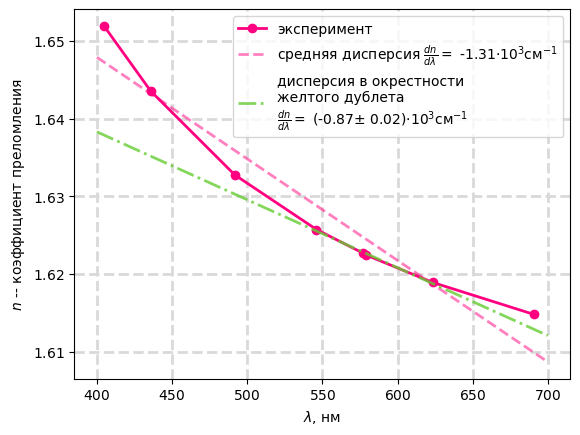

In [148]:
# расчет cредней дисперсии
def linear(x, k, b):
    return k*x + b
popt, pcov = opt.curve_fit(linear, 
                             data1["lambda, nm"], 
                             data1["n"], 
                             sigma = data1["delta_n"], 
                             absolute_sigma = True)
k = popt[0]
b = popt[1]
delta_k = pcov[0][0]**0.5
delta_b = pcov[1][1]**0.5

# аппроксимация полиномом
def square(x, c, d, e):
    return c*x**2 + d*x + e
popt, pcov = opt.curve_fit(square, 
                             data1["lambda, nm"], 
                             data1["n"], 
                             sigma = data1["delta_n"], 
                             absolute_sigma = True)
c = popt[0]
d = popt[1]
e = popt[2]
delta_c = pcov[0][0]**0.5
delta_d = pcov[1][1]**0.5
delta_e = pcov[2][2]**0.5

# дисперсия вблизи желтых линий
popt, pcov = opt.curve_fit(linear, 
                             data1["lambda, nm"].loc[[2, 1, 0, 6]], 
                             data1["n"].loc[[2, 1, 0, 6]], 
                             sigma = data1["delta_n"].loc[[2, 1, 0, 6]], 
                             absolute_sigma = True)
ky = popt[0]
by = popt[1]
delta_ky = pcov[0][0]**0.5
delta_by = pcov[1][1]**0.5

n0 = 0

x_th = np.linspace(400, 700, 100)

matplotlib.rcParams.update({'font.size': 10})
plt.grid(c = (0.85, 0.85, 0.85), ls = '--', lw = 2)

plt.plot(data1["lambda, nm"], data1["n"] - n0, 'o-', 
         color = raspberry_pink, 
         label = 'эксперимент')
plt.plot(x_th, k * x_th + b - n0, 
         color = raspberry_pink, ls = '--', alpha = 0.5,
         label = r"средняя дисперсия $\frac{dn}{d\lambda} =$" + f' {k*1e4:.2f}' + r'$\cdot 10^{3} \text{см}^{-1}$')
#plt.plot(x_th, square(x_th, c, d, e) - n0,
#         color = light_green)
plt.plot(x_th, ky * x_th + by - n0, 
         color = light_green, ls = '-.', alpha = 0.8,
         label = 'дисперсия в окрестности\nжелтого дублета\n'+ r"$\frac{dn}{d\lambda} =$" + f' ({ky*1e4:.2f}' + r'$\pm$' + f' {delta_ky*1e4:.2f})'+ r'$\cdot 10^{3} \text{см}^{-1}$')

plt.xlabel(r"$\lambda$, нм")
plt.ylabel(r"$n$ -- коэффициент преломления")
plt.legend()
plt.savefig('pics/graph.png', dpi = 300)
k, delta_k


In [87]:
# число аббе
nF = square(486.1, c, d, e) # голубая линия водорода
nD = square(589.8, c, d, e) # желтый дублет натрия
nC = square(656.3, c, d, e) # красная линия водорода
(nD - 1)/(nF - nC)

33.96890970939631

# Оценка спектральных характеристик
## 1) угловая дисперсия

In [88]:
# углы желтых компонент (в секундах)

a1_min = 308*3600+2*60+6
a1_max = 308*3600+2*60+37

a2_min = 308*3600+3*60+21
a2_max = 308*3600+3*60+51

a1 = (a1_min + a1_max)/2
a2 = (a2_min + a2_max)/2

delta_a1 = delta1
delta_a2 = delta1

#разность углов
da = a2 - a1
delta_da = (delta_a1**2 + delta_a2**2)**0.5

# разность длин волн
d_lam = 2.1 #нм

# средний показатель преломления для желтых линий
n = 1.6225

# средний угол отклонения в секундах
theta = (187066 + 187163)/2
delta_theta = (delta1**2 + delta2**2 + ((187066 - 187163)/2)**2)**0.5

theta, delta_theta

(187114.5, 60.01874707122767)

In [ ]:
# экспериментальная угловая дисперсия
D_exp = da/d_lam
delta_D_exp = delta_da/d_lam

# теоретическая угловая дисперсия
D_th = 2 * np.sin(a/2 / 3600 /180 * np.pi)/np.cos(theta/ 3600 /180 * np.pi)* ky
delta_D_th = ((2 * np.cos(a/2 / 3600 /180 * np.pi)/np.cos(theta/ 3600 /180 * np.pi)* k/2)**2 * (delta_a/180/3600*np.pi)**2 +
              (2 * np.sin(a/2 / 3600 /180 * np.pi)*np.sin(theta/ 3600 /180 * np.pi)/np.cos(theta/ 3600 /180 * np.pi)**2 * k)**2 * (delta_theta/180/3600*np.pi)**2+
              (2 * np.sin(a/2 / 3600 /180 * np.pi)/np.cos(theta/ 3600 /180 * np.pi)* delta_ky)**2)**0.5

D_th*3600*180/np.pi, delta_D_th*3600*180/np.pi

(-30.32875076750034, 0.7312035634269772)

In [135]:
D_exp, delta_D_exp

(35.476190476190474, 3.367175148507369)

## 2) разрешающая способность

In [143]:
# длина волны
lam1 = 577.0

# минимальная угловая ширина
dth = 15
delta_dth = 5

# экспериментальная разрешающая способность
R = lam1*D_exp/dth
delta_R = R * ((delta_D_exp/D_exp)**2+(delta_dth/dth)**2)**0.5
R, delta_R

(1364.6507936507937, 472.9646448177849)

In [ ]:
# эффективная длина призмы
l_exp = R/ky
delta_l_exp = l_exp *((delta_R/R)**2+(delta_ky/ky)**2)**0.5
l_exp*1e-7, delta_l_exp*1e-7 #см

(-1.5607851947740095, -0.5422479943793138)

In [152]:
# ширина пучка
width = np.cos(theta/ 3600 /180 * np.pi)/2 / np.sin(a/2 / 3600 /180 * np.pi)*l_exp
delta_width = ((np.sin(theta/ 3600 /180 * np.pi)/2 / np.sin(a/2 / 3600 /180 * np.pi)*l_exp)**2 * (delta_theta/ 3600 /180 * np.pi)**2 +
               (np.cos(theta/ 3600 /180 * np.pi)*np.cos(a/2 / 3600 /180 * np.pi) /2 / np.sin(a/2 / 3600 /180 * np.pi)**2 *l_exp)**2 * (delta_a/2 / 3600 /180 * np.pi)**2 +
               (np.cos(theta/ 3600 /180 * np.pi)/2 / np.sin(a/2 / 3600 /180 * np.pi)*delta_l_exp)**2)**0.5
width*1e-7, delta_width*1e-7 #см

(-0.9280943804944144, 0.32243873796410577)

In [153]:
# максимально возможная разрешающая способность
l = 7.2 #см
delta_l = 0.1 # см
R_max = l * ky *1e7
delta_R_max = R_max*((delta_l/l)**2+(delta_ky/ky)**2)**0.5
R_max, delta_R_max

(-6295.219705558762, -175.12077011538403)

# Оценка дисперсионной области

In [8]:
def n(w, w0, wp, gamma):
    return 1 + wp**2/2 * (w0**2-w**2)/((w0**2-w**2)**2+4 *gamma**2*w**2)

c = 3e17 #nm/s
data1['omega'] = 2 * np.pi * c/data1['lambda, nm']
popt, pcov = opt.curve_fit(n, 
                             data1["omega"], 
                             data1["n"], 
                             sigma = data1["delta_n"], 
                             absolute_sigma = True)
w0 = popt[0]
wp = popt[1]
gamma = popt[2]

w0, wp, gamma


c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\optimize\_minpack_py.py:1010: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


(1.0, 1.0, 1.0)